# YUVAA Internship — Week 1
## Exploratory Data Analysis of Crop Production in India

**Prepared by:** Avirup Karmakar

This notebook documents the Week 1 workflow: dataset loading, data-quality assessment, cleaning, descriptive statistics, exploratory analysis, visualization, and initial findings.

**Dataset:** `crop_production.csv`

**Columns:** `State_Name`, `District_Name`, `Crop_Year`, `Season`, `Crop`, `Area`, `Production`

> **Cleaning decision:** 3,730 missing values were identified in `Production`. They are excluded from production-based analysis rather than replaced with zero.


## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Load Dataset

In [4]:
df = pd.read_csv("crop_production.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
display(df.head())


Dataset loaded successfully!
Rows: 246091
Columns: 8


,index,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


## 3. Initial Inspection

In [5]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nDataset information:")
df.info()


Column names:
['index', 'State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production']

Data types:


,Data Type
index,int64
State_Name,object
District_Name,object
Crop_Year,int64
Season,object
Crop,object
Area,float64
Production,float64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   index          246091 non-null  int64  
 1   State_Name     246091 non-null  object 
 2   District_Name  246091 non-null  object 
 3   Crop_Year      246091 non-null  int64  
 4   Season         246091 non-null  object 
 5   Crop           246091 non-null  object 
 6   Area           246091 non-null  float64
 7   Production     242361 non-null  float64
dtypes: float64(2), int64(2), object(4)
memory usage: 15.0+ MB


In [6]:
print("Descriptive overview:")
display(df.describe(include="all").T)


Descriptive overview:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
index,246091.0,NaN,NaN,NaN,123045.0,71040.496885,0.0,61522.5,123045.0,184567.5,246090.0
State_Name,246091,33,Uttar Pradesh,33306,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District_Name,246091,646,BIJAPUR,945,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop_Year,246091.0,NaN,NaN,NaN,2005.643018,4.952164,1997.0,2002.0,2006.0,2010.0,2015.0
Season,246091,6,Kharif,95951,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,246091,124,Rice,15104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,246091.0,NaN,NaN,NaN,12002.820864,50523.404019,0.04,80.0,582.0,4392.0,8580100.0
Production,242361.0,NaN,NaN,NaN,582503.442251,17065813.17241,0.0,88.0,729.0,7023.0,1250800000.0


## 4. Missing-Value Analysis

In [7]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})
display(missing_summary)


,Missing Values,Missing Percentage
index,0,0.00
State_Name,0,0.00
District_Name,0,0.00
Crop_Year,0,0.00
Season,0,0.00
Crop,0,0.00
Area,0,0.00
Production,3730,1.52


### Missing-value treatment

`Production` contains **3,730** missing values. Because production is a key variable for the analysis, these rows are removed from production-based calculations. Missing production is not assumed to mean zero production.


## 5. Duplicate and Validity Checks

In [8]:
print("Duplicate rows:", int(df.duplicated().sum()))
print("Negative Area values:", int((pd.to_numeric(df["Area"], errors="coerce") < 0).sum()))
print("Negative Production values:", int((pd.to_numeric(df["Production"], errors="coerce") < 0).sum()))


Duplicate rows: 0
Negative Area values: 0
Negative Production values: 0


## 6. Data Cleaning and Preprocessing

In [9]:
df.columns = df.columns.str.strip()

for column in ["State_Name", "District_Name", "Season", "Crop"]:
    df[column] = df[column].astype("string").str.strip()

df["Crop_Year"] = pd.to_numeric(df["Crop_Year"], errors="coerce")
df["Area"] = pd.to_numeric(df["Area"], errors="coerce")
df["Production"] = pd.to_numeric(df["Production"], errors="coerce")

# Remove duplicate rows
df = df.drop_duplicates()

# Keep cleaned dataset
cleaned_df = df.copy()

# Exclude missing/invalid values only for analytical calculations
analysis_df = cleaned_df.dropna(
    subset=["Crop_Year", "Area", "Production"]
).copy()

analysis_df = analysis_df[
    (analysis_df["Area"] >= 0) &
    (analysis_df["Production"] >= 0)
].copy()

print("Cleaned dataset shape:", cleaned_df.shape)
print("Analysis dataset shape:", analysis_df.shape)


Cleaned dataset shape: (246091, 8)
Analysis dataset shape: (242361, 8)


In [10]:
print("Missing values after cleaning:")
display(cleaned_df.isnull().sum())

print("Duplicate rows after cleaning:", int(cleaned_df.duplicated().sum()))
display(cleaned_df.dtypes.to_frame("Data Type"))


Missing values after cleaning:


,0
index,0
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Area,0
Production,3730


Duplicate rows after cleaning: 0


,Data Type
index,int64
State_Name,string[python]
District_Name,string[python]
Crop_Year,int64
Season,string[python]
Crop,string[python]
Area,float64
Production,float64


In [11]:
cleaned_df.to_csv("crop_production_cleaned.csv", index=False)
print("Saved: crop_production_cleaned.csv")


Saved: crop_production_cleaned.csv


## 7. Dataset Profile

In [12]:
print("Number of states/regions:", analysis_df["State_Name"].nunique())
print("Number of districts:", analysis_df["District_Name"].nunique())
print("Number of crops:", analysis_df["Crop"].nunique())
print("Number of seasons:", analysis_df["Season"].nunique())
print("Year range:", int(analysis_df["Crop_Year"].min()), "-", int(analysis_df["Crop_Year"].max()))

print("\nSeason counts:")
display(analysis_df["Season"].value_counts())


Number of states/regions: 33
Number of districts: 646
Number of crops: 124
Number of seasons: 6
Year range: 1997 - 2015

Season counts:


,count
Season,
Kharif,94283
Rabi,66160
Whole Year,56127
Summer,14811
Winter,6050
Autumn,4930


## 8. Descriptive Statistics

In [13]:
display(
    analysis_df[["Crop_Year", "Area", "Production"]].describe()
)


,Crop_Year,Area,Production
count,242361.000000,2.423610e+05,2.423610e+05
mean,2005.625773,1.216741e+04,5.825034e+05
std,4.958285,5.085744e+04,1.706581e+07
min,1997.000000,1.000000e-01,0.000000e+00
25%,2002.000000,8.700000e+01,8.800000e+01
50%,2006.000000,6.030000e+02,7.290000e+02
75%,2010.000000,4.545000e+03,7.023000e+03
max,2015.000000,8.580100e+06,1.250800e+09


## 9. Crop-wise Production Analysis

In [14]:
crop_production = (
    analysis_df.groupby("Crop")["Production"]
    .sum()
    .sort_values(ascending=False)
)

display(crop_production.head(10).to_frame("Total Production"))


,Total Production
Crop,
Coconut,1.299816e+11
Sugarcane,5.535682e+09
Rice,1.605470e+09
Wheat,1.332826e+09
Potato,4.248263e+08
Cotton(lint),2.970000e+08
Maize,2.733418e+08
Jute,1.815582e+08
Banana,1.461327e+08


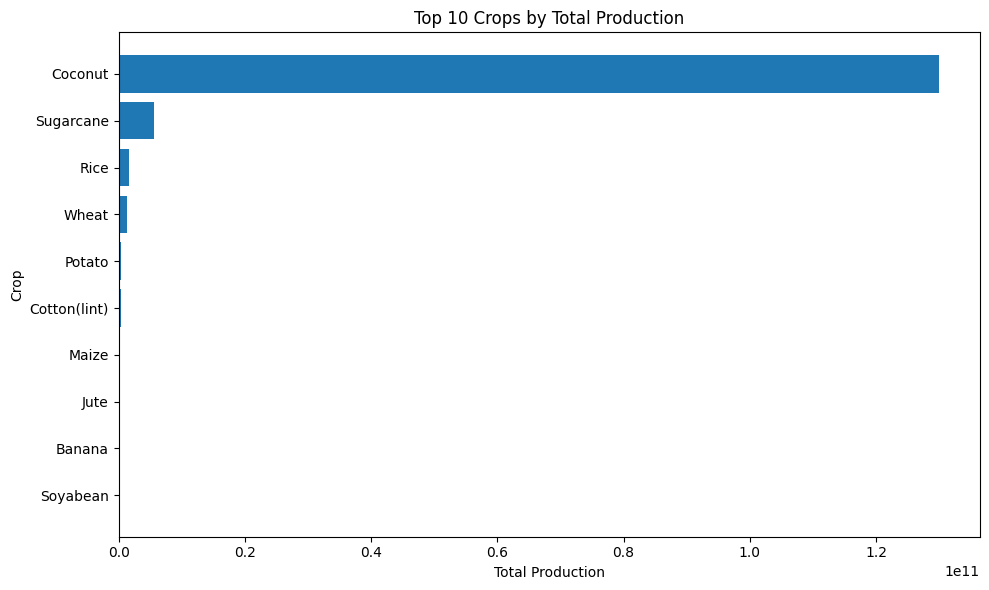

In [15]:
top_crops = crop_production.head(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top_crops.index, top_crops.values)
plt.title("Top 10 Crops by Total Production")
plt.xlabel("Total Production")
plt.ylabel("Crop")
plt.tight_layout()
plt.savefig("top_10_crops.png", dpi=300)
plt.show()


## 10. State-wise Production Analysis

In [16]:
state_production = (
    analysis_df.groupby("State_Name")["Production"]
    .sum()
    .sort_values(ascending=False)
)

display(state_production.head(10).to_frame("Total Production"))


,Total Production
State_Name,
Kerala,9.788005e+10
Andhra Pradesh,1.732459e+10
Tamil Nadu,1.207644e+10
Uttar Pradesh,3.234493e+09
Assam,2.111752e+09
West Bengal,1.397904e+09
Maharashtra,1.263641e+09
Karnataka,8.634298e+08
Andaman and Nicobar Islands,7.182232e+08


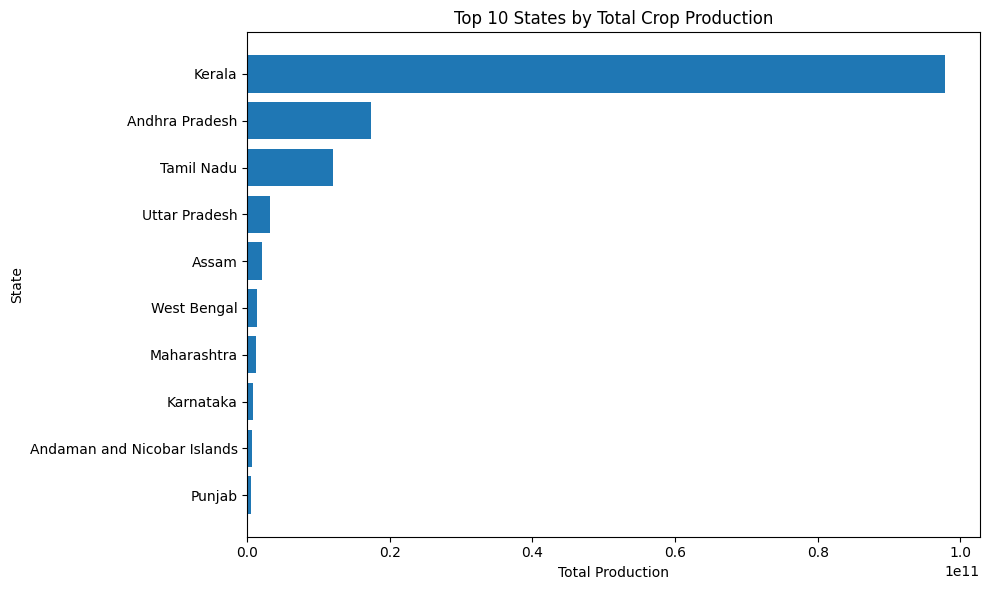

In [17]:
top_states = state_production.head(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top_states.index, top_states.values)
plt.title("Top 10 States by Total Crop Production")
plt.xlabel("Total Production")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("top_10_states.png", dpi=300)
plt.show()


## 11. District-wise Production Analysis

In [18]:
district_production = (
    analysis_df.groupby(["State_Name", "District_Name"])["Production"]
    .sum()
    .sort_values(ascending=False)
)

display(district_production.head(10).to_frame("Total Production"))


Total Production
State_Name     District_Name                       
Kerala         KOZHIKODE               1.528074e+10
               MALAPPURAM              1.451840e+10
               THIRUVANANTHAPURAM      1.002271e+10
               THRISSUR                9.923508e+09
               KANNUR                  9.783432e+09
Andhra Pradesh EAST GODAVARI           8.271057e+09
Kerala         KASARAGOD               7.732217e+09
               KOLLAM                  7.151945e+09
               PALAKKAD                6.369382e+09
               ERNAKULAM               5.021649e+09

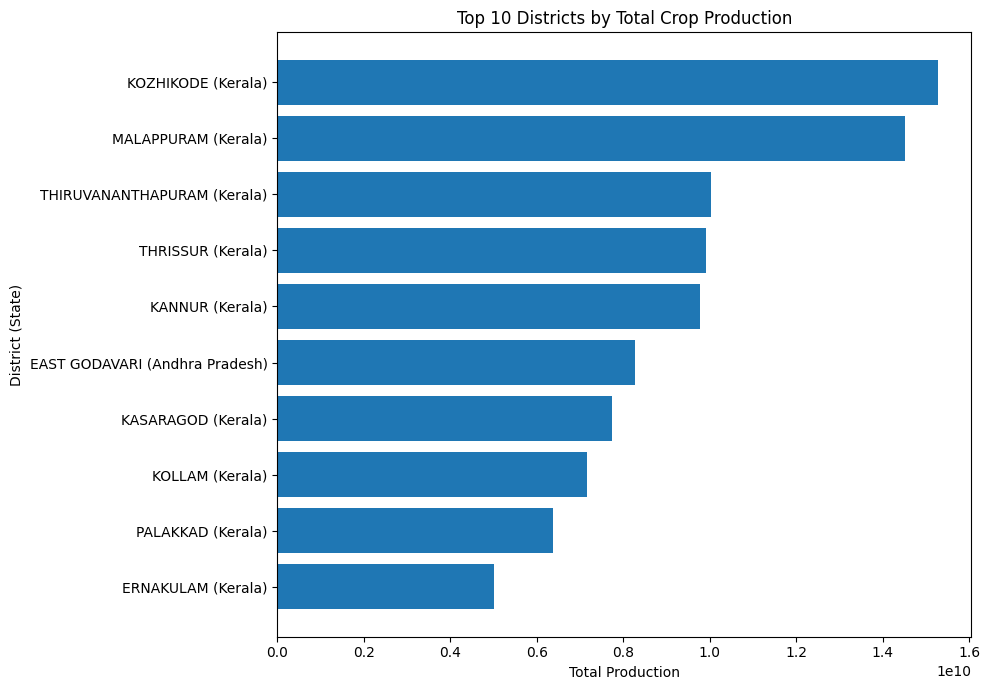

In [19]:
top_districts = district_production.head(10).sort_values()
labels = [f"{district} ({state})" for state, district in top_districts.index]

plt.figure(figsize=(10, 7))
plt.barh(labels, top_districts.values)
plt.title("Top 10 Districts by Total Crop Production")
plt.xlabel("Total Production")
plt.ylabel("District (State)")
plt.tight_layout()
plt.savefig("top_10_districts.png", dpi=300)
plt.show()


## 12. Season-wise Production Analysis

In [20]:
season_production = (
    analysis_df.groupby("Season")["Production"]
    .sum()
    .sort_values(ascending=False)
)

display(season_production.to_frame("Total Production"))


,Total Production
Season,
Whole Year,1.344248e+11
Kharif,4.029970e+09
Rabi,2.051688e+09
Winter,4.345498e+08
Summer,1.706579e+08
Autumn,6.441377e+07


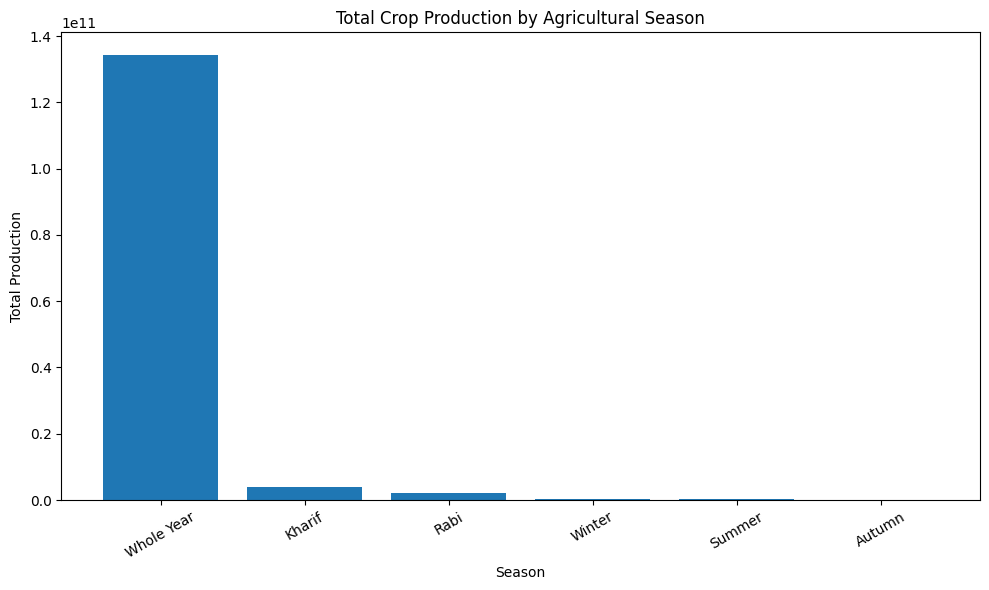

In [21]:
plt.figure(figsize=(10, 6))
plt.bar(season_production.index, season_production.values)
plt.title("Total Crop Production by Agricultural Season")
plt.xlabel("Season")
plt.ylabel("Total Production")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("production_by_season.png", dpi=300)
plt.show()


## 13. Year-wise Production Analysis

In [22]:
yearly_production = (
    analysis_df.groupby("Crop_Year")["Production"]
    .sum()
    .sort_index()
)

display(yearly_production.to_frame("Total Production"))


,Total Production
Crop_Year,
1997,8.512329e+08
1998,5.825321e+09
1999,6.434666e+09
2000,7.449709e+09
2001,7.465541e+09
2002,7.696955e+09
2003,7.917974e+09
2004,8.189462e+09
2005,8.043757e+09


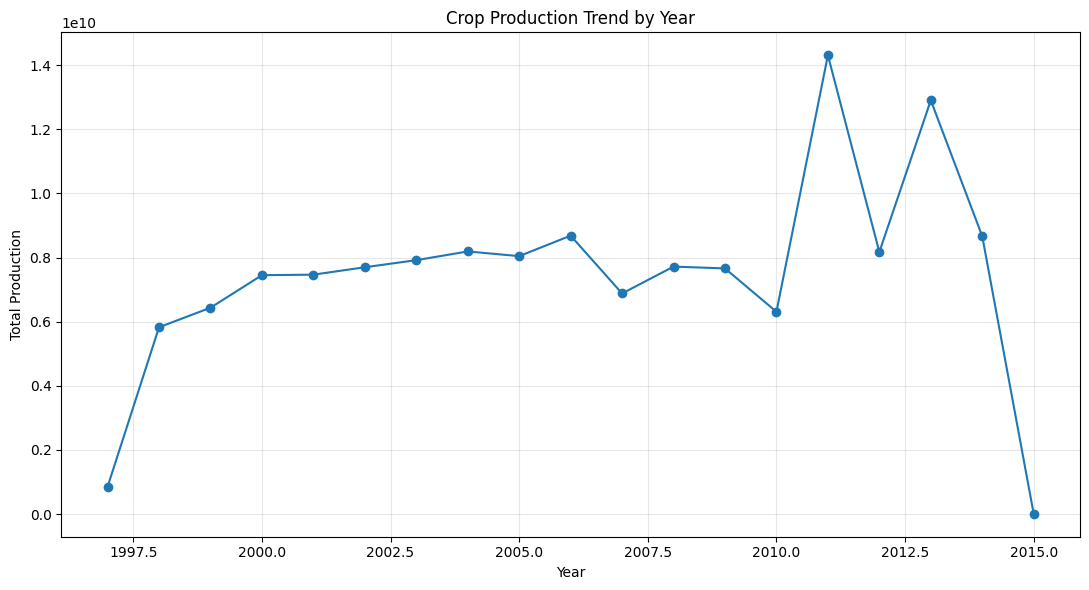

In [23]:
plt.figure(figsize=(11, 6))
plt.plot(yearly_production.index, yearly_production.values, marker="o")
plt.title("Crop Production Trend by Year")
plt.xlabel("Year")
plt.ylabel("Total Production")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("production_trend.png", dpi=300)
plt.show()


## 14. Year-over-Year Growth

In [24]:
yearly_growth = yearly_production.pct_change() * 100

growth_table = pd.DataFrame({
    "Year": yearly_growth.index,
    "Production Growth (%)": yearly_growth.values
})
display(growth_table)

valid_growth = yearly_growth.dropna()
if not valid_growth.empty:
    print("Highest YoY growth:", int(valid_growth.idxmax()), f"({valid_growth.max():.2f}%)")
    print("Largest YoY decline:", int(valid_growth.idxmin()), f"({valid_growth.min():.2f}%)")


,Year,Production Growth (%)
0,1997,NaN
1,1998,584.339221
2,1999,10.460288
3,2000,15.774605
4,2001,0.212515
5,2002,3.099766
6,2003,2.871504
7,2004,3.428759
8,2005,-1.779169
9,2006,7.933554


Highest YoY growth: 1998 (584.34%)
Largest YoY decline: 2015 (-99.92%)


## 15. Cultivated Area Analysis

In [25]:
yearly_area = (
    analysis_df.groupby("Crop_Year")["Area"]
    .sum()
    .sort_index()
)

display(yearly_area.to_frame("Total Area"))


,Total Area
Crop_Year,
1997,2.317150e+08
1998,1.666316e+08
1999,1.586125e+08
2000,1.652898e+08
2001,1.652927e+08
2002,1.573286e+08
2003,1.697655e+08
2004,1.677566e+08
2005,1.629203e+08


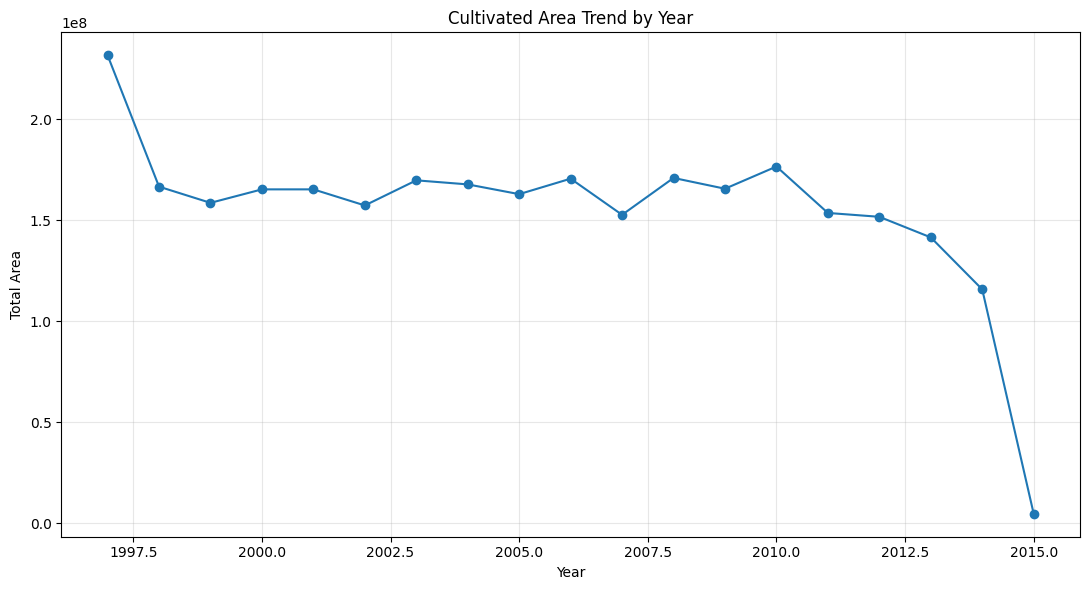

In [26]:
plt.figure(figsize=(11, 6))
plt.plot(yearly_area.index, yearly_area.values, marker="o")
plt.title("Cultivated Area Trend by Year")
plt.xlabel("Year")
plt.ylabel("Total Area")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("area_trend.png", dpi=300)
plt.show()


## 16. Area vs Production

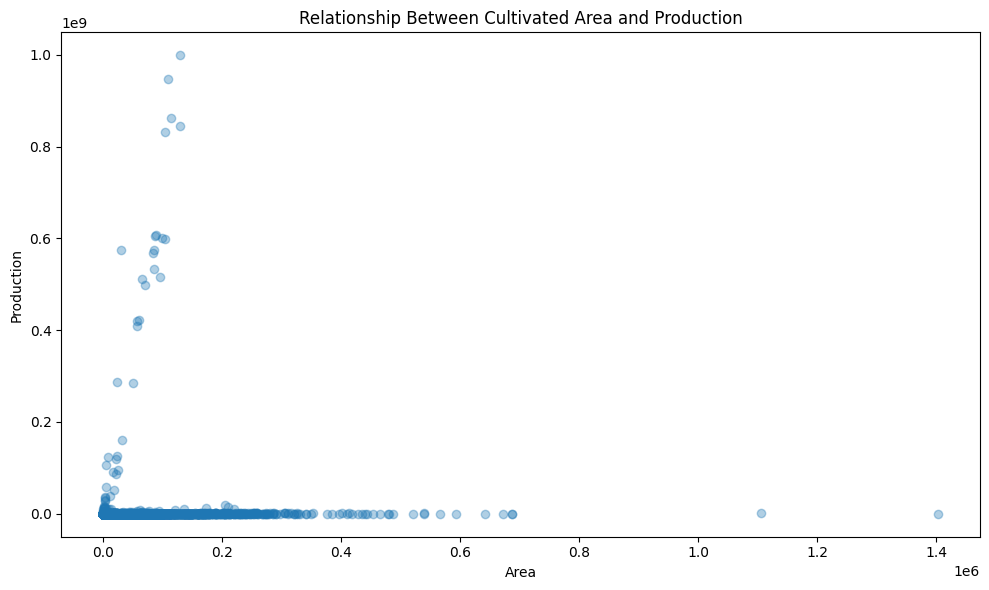

In [27]:
sample_df = analysis_df.sample(
    n=min(15000, len(analysis_df)),
    random_state=42
)

plt.figure(figsize=(10, 6))
plt.scatter(sample_df["Area"], sample_df["Production"], alpha=0.35)
plt.title("Relationship Between Cultivated Area and Production")
plt.xlabel("Area")
plt.ylabel("Production")
plt.tight_layout()
plt.savefig("area_vs_production.png", dpi=300)
plt.show()


## 17. Correlation Analysis

In [28]:
correlation_matrix = analysis_df[["Area", "Production"]].corr()
display(correlation_matrix)

area_production_corr = analysis_df["Area"].corr(
    analysis_df["Production"]
)
print(f"Area-Production correlation: {area_production_corr:.3f}")


,Area,Production
Area,1.000000,0.040587
Production,0.040587,1.000000


Area-Production correlation: 0.041


## 18. Highest Production Record

In [29]:
highest_record = analysis_df.loc[
    analysis_df["Production"].idxmax()
]
display(highest_record.to_frame("Value"))


,Value
index,178273
State_Name,Tamil Nadu
District_Name,COIMBATORE
Crop_Year,2011
Season,Whole Year
Crop,Coconut
Area,82704.0
Production,1250800000.0


## 19. Key Findings Summary

In [30]:
print("Highest-production crop:", crop_production.index[0])
print("Highest-production state:", state_production.index[0])
print(
    "Highest-production district:",
    district_production.index[0][1],
    f"({district_production.index[0][0]})"
)
print("Highest-production season:", season_production.index[0])
print("Highest-production year:", int(yearly_production.idxmax()))
print("Area-Production correlation:", round(area_production_corr, 3))


Highest-production crop: Coconut
Highest-production state: Kerala
Highest-production district: KOZHIKODE (Kerala)
Highest-production season: Whole Year
Highest-production year: 2011
Area-Production correlation: 0.041


## 20. Conclusion

Week 1 establishes a reproducible agricultural data-analysis workflow. The dataset is inspected, cleaned, summarized and explored across crop, state, district, season and year dimensions. Visual analysis is used to communicate trends and relationships. The resulting cleaned dataset can serve as the foundation for later agricultural analytics and predictive modelling.

**Note:** Interpretations in the final report should use the actual outputs generated by this notebook. Correlation should not be described as proof of causation.
